In [2]:
# ============================================================================
# CELL 1 — catalogue all filtered DeepLabCut h5 files + assign groups
# ============================================================================
# NOTE: read_hdf needs pytables. If it errors, run once: pip install tables
from pathlib import Path
import re
import pandas as pd

DLC_ROOT = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions"
                r"\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_DLC_multiAnimal")

# ---- MR dataset IDs ----
Agg = ["975826","975827","975833","978772","978774","988590","997838",
       "1010820","1010823","1010826","1029741"]
nonAgg = ["975830","978775","1010819","997839","997840","997841",
          "1029736","1029739","1032216"]
maladaptive = ["978513","978527","978528","1010832","1013590","1034805","1034814"]

saline_mice = maladaptive[:3]     # 978513, 978527, 978528
psilo_mice  = maladaptive[3:]     # 1010832, 1013590, 1034805, 1034814

# ---- find all filtered tracking files (skeleton variant only) ----
h5_files = sorted(DLC_ROOT.rglob("*_sk_filtered.h5"))
h5_files = [p for p in h5_files if "skeleton" in str(p).lower()]

rows, skipped = [], []
for p in h5_files:
    m = re.search(r"mouse(\d+)_Day(\d+)", p.name)
    if not m:
        skipped.append({"file": p.name, "reason": "regex_no_match"}); continue
    mouse, day = m.group(1), int(m.group(2))

    if mouse in Agg:
        group = "Agg"
    elif mouse in nonAgg:
        group = "nonAgg"
    elif mouse in maladaptive and day <= 5:
        group = "maladaptive baseline"
    elif mouse in psilo_mice and day >= 15:
        group = "maladaptive after Psilocybin"
    elif mouse in saline_mice and day >= 15:
        group = "maladaptive after Saline"
    else:
        skipped.append({"file": p.name, "mouse": mouse, "day": day,
                        "reason": "mouse_day_not_assigned"}); continue

    rows.append({
        "path": str(p),
        "video": p.name.replace("_sk_filtered.h5", "_sk"),   # matches your other pipelines' 'video' key
        "mouse": mouse,
        "mouse_group_id": f"{mouse}_{group}",
        "day": day,
        "group": group,
    })

dlc_files   = pd.DataFrame(rows).sort_values(["mouse", "day"]).reset_index(drop=True)
skipped_dlc = pd.DataFrame(skipped)

print(f"{len(dlc_files)} filtered h5 files  |  {dlc_files['mouse'].nunique()} mice")
print(dlc_files["group"].value_counts().to_string())
print(f"\nskipped {len(skipped_dlc)}")
if len(skipped_dlc):
    print(skipped_dlc["reason"].value_counts().to_string())
# CELL 2's extract_dlc_features() reads one file at a time from dlc_files["path"].

237 filtered h5 files  |  27 mice
group
Agg                             95
nonAgg                          86
maladaptive baseline            32
maladaptive after Psilocybin    12
maladaptive after Saline        12

skipped 0


In [37]:
#   scope tag:  res | int | rel     (resident-only / intruder-only / relationship)
#   kind  tag:  centroid | heading | keypoint
#       centroid = derived from the low-noise centroid (speed, accel, jerk, bouts,
#                  distance, approach, lead-lag, joint/relative speed)
#       heading  = needs body orientation (turning, body length, facing, alignment, chasing, behind)
#       keypoint = needs specific keypoints (midPoint speed, midPoint-directed dists, keypoint contact)
# ============================================================================
import numpy as np
import pandas as pd
import warnings
from scipy.stats import entropy, skew, kurtosis
 
BODY_PARTS = ["nose", "rightEar", "leftEar", "neckBase", "betNeckBaseAndMidPoint",
              "midPoint", "betMidPointAndTailBase", "tailBase", "tailMid", "tailTip"]
 
 
def _shannon(x, bins=30):
    x = np.asarray(x); x = x[np.isfinite(x)]
    if len(x) == 0 or np.all(x == x[0]): return 0.0
    h, _ = np.histogram(x, bins=bins, density=True); h = h + 1e-12; h = h / h.sum()
    return float(entropy(h, base=2))
 
 
def _bouts(mask):
    mask = np.asarray(mask, bool)
    if mask.size == 0: return 0, 0.0, 0.0
    d = np.diff(mask.astype(int)); s = np.where(d == 1)[0] + 1; e = np.where(d == -1)[0] + 1
    if mask[0]: s = np.r_[0, s]
    if mask[-1]: e = np.r_[e, len(mask)]
    dur = e - s
    if len(dur) == 0: return 0, 0.0, 0.0
    return int(len(dur)), float(dur.mean()), float(dur.max())
 
 
def _interp(a):
    a = a.copy(); n = len(a); idx = np.arange(n); g = np.isfinite(a)
    if g.sum() < 2: return a
    a[~g] = np.interp(idx[~g], idx[g], a[g]); return a
 
 
def _keypoints(df_ind, pcutoff, smooth_win=5):
    parts = [b for b in BODY_PARTS if b in df_ind.columns.get_level_values("bodyparts")]
    K = {}
    for b in parts:
        x = np.array(df_ind[(b, "x")], float); y = np.array(df_ind[(b, "y")], float)
        lk = np.array(df_ind[(b, "likelihood")], float); bad = ~(lk >= pcutoff)
        x[bad] = np.nan; y[bad] = np.nan
        x, y = _interp(x), _interp(y)
        if smooth_win > 1:
            x = pd.Series(x).rolling(smooth_win, center=True, min_periods=1).median().to_numpy()
            y = pd.Series(y).rolling(smooth_win, center=True, min_periods=1).median().to_numpy()
        K[b] = (x, y)
    return K, parts
 
 
def _kin(cx, cy, fps):
    vx = np.gradient(cx) * fps; vy = np.gradient(cy) * fps
    speed = np.hypot(vx, vy)
    ax = np.gradient(vx) * fps; ay = np.gradient(vy) * fps
    acc = np.hypot(ax, ay)
    jerk = np.hypot(np.gradient(ax) * fps, np.gradient(ay) * fps)
    return vx, vy, speed, acc, jerk
 
 
def _motion_block(speed, acc, jerk, fps, p):
    med = np.median(speed); mad = np.median(np.abs(speed - med)) + 1e-8; z = (speed - med) / mad
    bc3, mb3, xb3 = _bouts(z > 3); n = len(speed); e, l = speed[:n // 3], speed[2 * n // 3:]
    return {
        f"{p}_speed_mean": float(np.mean(speed)), f"{p}_speed_median": float(np.median(speed)),
        f"{p}_speed_std": float(np.std(speed)),   f"{p}_speed_p95": float(np.percentile(speed, 95)),
        f"{p}_speed_entropy": _shannon(speed),
        f"{p}_frac_fast_z3": float(np.mean(z > 3)), f"{p}_frac_fast_z5": float(np.mean(z > 5)),
        f"{p}_bout_count_z3": bc3, f"{p}_bout_mean_dur_z3": mb3, f"{p}_bout_max_dur_z3": xb3,
        f"{p}_accel_mean": float(np.mean(acc)), f"{p}_accel_p95": float(np.percentile(acc, 95)),
        f"{p}_jerk_mean": float(np.mean(jerk)), f"{p}_jerk_p95": float(np.percentile(jerk, 95)),
        f"{p}_path_length": float(np.nansum(speed) / fps), f"{p}_frac_moving": float(np.mean(z > 1)),
        f"{p}_early_speed": float(np.mean(e)), f"{p}_late_speed": float(np.mean(l)),
    }
 
 
def _compute_all_features(h5_path, pcutoff=0.8, fps=50, smooth_win=5,
                          contact_bl=0.5, near_bl=1.5, cos_thr=0.5):
    """Full 81-feature dict (both animals + relationship). Filtering happens in extract_dlc_features()."""
    df = pd.read_hdf(h5_path); df.columns = df.columns.droplevel("scorer")
    feats = {}; A = {}
    for ind, pref in [("Resident", "res"), ("Intruder", "int")]:
        K, parts = _keypoints(df[ind], pcutoff, smooth_win)
        Kx = np.vstack([K[b][0] for b in parts]); Ky = np.vstack([K[b][1] for b in parts])
        cx = np.nanmean(Kx, 0); cy = np.nanmean(Ky, 0)
        midPoint, tail = K["midPoint"], K["tailBase"]
        hx = midPoint[0] - tail[0]; hy = midPoint[1] - tail[1]
        blen = np.hypot(hx, hy); heading = np.arctan2(hy, hx)
        ang_vel = np.abs(np.gradient(np.unwrap(heading)) * fps)
        _, _, nspeed, _, _ = _kin(midPoint[0], midPoint[1], fps)
        vx, vy, speed, acc, jerk = _kin(cx, cy, fps)
        A[pref] = dict(cx=cx, cy=cy, vx=vx, vy=vy, speed=speed, heading=heading,
                       blen=blen, midPoint=midPoint, tail=tail, Kx=Kx, Ky=Ky)
        feats.update(_motion_block(speed, acc, jerk, fps, pref))
        feats[f"{pref}_midpoint_speed_mean"] = float(np.mean(nspeed))
        feats[f"{pref}_midpoint_speed_p95"] = float(np.percentile(nspeed, 95))
        feats[f"{pref}_ang_vel_mean"] = float(np.mean(ang_vel))
        feats[f"{pref}_ang_vel_p95"] = float(np.percentile(ang_vel, 95))
        feats[f"{pref}_body_len_mean"] = float(np.nanmean(blen))
        feats[f"{pref}_body_len_cv"] = float(np.nanstd(blen) / (np.nanmean(blen) + 1e-8))
 
    R, I = A["res"], A["int"]
    BL = np.nanmedian(np.r_[R["blen"], I["blen"]]) + 1e-8
 
    dx = I["cx"] - R["cx"]; dy = I["cy"] - R["cy"]; dist = np.hypot(dx, dy); distBL = dist / BL
    feats.update({"dist_mean_bl": float(np.nanmean(distBL)), "dist_median_bl": float(np.nanmedian(distBL)),
                  "dist_min_bl": float(np.nanmin(distBL)), "frac_near": float(np.mean(distBL < near_bl))})
 
    mind = np.full(len(dist), np.inf)
    for i in range(R["Kx"].shape[0]):
        mind = np.minimum(mind, np.nanmin(np.hypot(I["Kx"] - R["Kx"][i], I["Ky"] - R["Ky"][i]), 0))
    mindBL = mind / BL; contact = mindBL < contact_bl
    cc, cm, _ = _bouts(contact)
    feats.update({"min_kp_dist_bl": float(np.nanmedian(mindBL)), "frac_contact": float(np.mean(contact)),
                  "contact_bout_count": cc, "contact_bout_mean_dur": cm,
                  "contact_rate_per_min": float(cc / (len(dist) / fps / 60 + 1e-8))})
 
    _d = lambda p, q: np.hypot(p[0] - q[0], p[1] - q[1]) / BL
    feats["res_midpoint_to_int_body_bl"] = float(np.nanmedian(_d(R["midPoint"], (I["cx"], I["cy"]))))
    feats["res_midpoint_to_int_tail_bl"] = float(np.nanmedian(_d(R["midPoint"], I["tail"])))
    feats["midpoint_to_midpoint_bl"] = float(np.nanmedian(_d(R["midPoint"], I["midPoint"])))
    feats["int_midpoint_to_res_body_bl"] = float(np.nanmedian(_d(I["midPoint"], (R["cx"], R["cy"]))))
 
    ux = dx / (dist + 1e-8); uy = dy / (dist + 1e-8)
    res_face = np.cos(R["heading"]) * ux + np.sin(R["heading"]) * uy
    int_face = np.cos(I["heading"]) * (-ux) + np.sin(I["heading"]) * (-uy)
    feats["res_facing_mean"] = float(np.nanmean(res_face)); feats["frac_res_facing"] = float(np.nanmean(res_face > cos_thr))
    feats["int_facing_mean"] = float(np.nanmean(int_face)); feats["frac_int_facing"] = float(np.nanmean(int_face > cos_thr))
    feats["facing_asymmetry"] = feats["frac_res_facing"] - feats["frac_int_facing"]
    rel = np.cos(R["heading"] - I["heading"])
    feats["rel_orient_mean"] = float(np.nanmean(rel))
    feats["frac_antiparallel"] = float(np.nanmean(rel < -cos_thr))
    feats["frac_parallel"] = float(np.nanmean(rel > cos_thr))
 
    ddist = np.gradient(dist) * fps
    feats["frac_approaching"] = float(np.mean(ddist < 0))
    feats["approach_speed_mean_bl"] = float(-np.mean(ddist[ddist < 0]) / BL) if np.any(ddist < 0) else 0.0
    rmove = R["speed"] > np.median(R["speed"]); imove = I["speed"] > np.median(I["speed"])
    cos_toward = (R["vx"] * ux + R["vy"] * uy) / (R["speed"] + 1e-8)
    chase = (cos_toward > cos_thr) & (res_face > cos_thr) & rmove & imove & (ddist < 0)
    feats["frac_chasing"] = float(np.mean(chase))
    chb, chm, _ = _bouts(chase); feats.update({"chase_bout_count": chb, "chase_bout_mean_dur": chm})
    behind = ((R["cx"] - I["cx"]) * np.cos(I["heading"]) + (R["cy"] - I["cy"]) * np.sin(I["heading"])) < 0
    feats["frac_res_behind_int"] = float(np.mean(behind & (distBL < near_bl)))
 
    rs = R["speed"] - R["speed"].mean(); is_ = I["speed"] - I["speed"].mean()
    denom = (np.std(R["speed"]) * np.std(I["speed"]) * len(rs)) + 1e-8
    lags = np.arange(-int(0.5 * fps), int(0.5 * fps) + 1)
    xc = [np.sum(rs[max(0, -L):len(rs) - max(0, L)] * is_[max(0, L):len(is_) - max(0, -L)]) / denom for L in lags]
    feats["speed_xcorr_peak"] = float(np.max(xc))
    feats["speed_lead_lag_s"] = float(lags[int(np.argmax(xc))] / fps)
    feats["speed_corr"] = float(np.corrcoef(R["speed"], I["speed"])[0, 1])
    feats["joint_speed_mean"] = float(np.mean(R["speed"] + I["speed"]))
    feats["rel_speed_mean"] = float(np.mean(np.abs(R["speed"] - I["speed"])))
    feats["n_frames"] = int(len(dist))
    return feats
 
 
# ---------- tag each feature by scope and kind ----------
def feature_scope(name):
    if name == "n_frames": return "meta"
    REL = ("dist_", "frac_near", "min_kp", "contact", "midpoint_to_midpoint", "midpoint_to_int", "midpoint_to_res",
           "facing", "rel_orient", "antiparallel", "parallel", "approach", "frac_approaching",
           "chas", "behind", "speed_xcorr", "speed_lead_lag", "speed_corr", "joint_speed", "rel_speed")
    if any(t in name for t in REL): return "rel"
    if name.startswith("res_"): return "res"
    if name.startswith("int_"): return "int"
    return "rel"
 
 
def feature_kind(name):
    if name == "n_frames": return "meta"
    HEADING  = ("ang_vel", "body_len", "heading", "facing", "rel_orient", "antiparallel", "parallel", "chas", "behind")
    KEYPOINT = ("midpoint_speed", "contact", "min_kp", "midpoint_to")
    if any(t in name for t in HEADING): return "heading"
    if any(t in name for t in KEYPOINT): return "keypoint"
    return "centroid"
 
 
def _resolve(sel, alias, universe):
    items = [sel] if isinstance(sel, str) else list(sel)
    out = set()
    for x in items:
        v = alias.get(str(x).lower().strip())
        if v == "all":
            return set(universe)
        if v:
            out.add(v)
    return out or set(universe)
 
 
_SCOPE_ALIAS = {"res": "res", "resident": "res", "r": "res", "int": "int", "intruder": "int", "i": "int",
                "rel": "rel", "relationship": "rel", "relation": "rel", "social": "rel", "all": "all", "both": "all"}
_KIND_ALIAS  = {"centroid": "centroid", "cent": "centroid", "c": "centroid",
                "heading": "heading", "orientation": "heading", "orient": "heading", "pose": "heading", "h": "heading",
                "keypoint": "keypoint", "kp": "keypoint", "contact": "keypoint", "k": "keypoint", "all": "all"}
 
 
def extract_dlc_features(h5_path, include="all", feature_kind_sel="all", pcutoff=0.8, fps=50,
                         smooth_win=5, contact_bl=0.5, near_bl=1.5, cos_thr=0.5):
    """
    Filtered maDLC features.
      include          : "resident" | "intruder" | "relationship" | "all"   (list ok)
      feature_kind_sel : "centroid" | "heading" | "keypoint" | "all"        (list ok)
    Both filters combine (AND). 'n_frames' is always kept.
    """
    scopes = _resolve(include, _SCOPE_ALIAS, {"res", "int", "rel"})
    kinds  = _resolve(feature_kind_sel, _KIND_ALIAS, {"centroid", "heading", "keypoint"})
    full = _compute_all_features(h5_path, pcutoff, fps, smooth_win, contact_bl, near_bl, cos_thr)
    out = {k: v for k, v in full.items()
           if feature_scope(k) in scopes and feature_kind(k) in kinds}
    out["n_frames"] = full["n_frames"]
    return out

In [38]:
from tqdm.auto import tqdm
 
# ---- FILTERS (control both here) ----
INCLUDE      = "all"     # scope: "resident" | "intruder" | "relationship" | "all"   (list ok, e.g. ["intruder","relationship"])
FEATURE_KIND = "all"     # kind : "centroid" | "heading" | "keypoint" | "all"         (list ok, e.g. ["centroid","keypoint"])
 
feat_rows, feat_failed = [], []
for r in tqdm(dlc_files.itertuples(index=False), total=len(dlc_files), desc="DLC features"):
    try:
        f = extract_dlc_features(r.path, include=INCLUDE, feature_kind_sel=FEATURE_KIND)
        f.update({"video": r.video, "mouse": r.mouse,
                  "mouse_group_id": r.mouse_group_id, "day": r.day, "group": r.group})
        feat_rows.append(f)
    except Exception as e:
        feat_failed.append({"video": r.video, "error": repr(e)})
 
dlc_features_df = pd.DataFrame(feat_rows)
dlc_failed = pd.DataFrame(feat_failed)
print(f"{len(dlc_features_df)} sessions | {dlc_features_df.shape[1]} cols "
      f"| INCLUDE={INCLUDE} KIND={FEATURE_KIND} | {len(dlc_failed)} failed")
if len(dlc_failed):
    print(dlc_failed.to_string(index=False))

DLC features:   0%|          | 0/237 [00:00<?, ?it/s]

236 sessions | 86 cols | INCLUDE=all KIND=all | 1 failed
                                                                                                                   video                                                                                                                                                                                                                                                                                                                                                                                                  error
mouse978775_Day11_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk FileNotFoundError('File C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\trainingSessions_topView_DLC_multiAnimal\\trainingSessions_topView_DLC_multiAnimal\\mouse978775\\topView_DLCtracking_pcutoff_0.8_skeleton\\mouse978775_Day11_topView_compDLC_Resnet101_trainingAggression_traini

group_merged
Agg            11
nonAgg          9
maladaptive     7
[feature selection] none -> 80/80 features


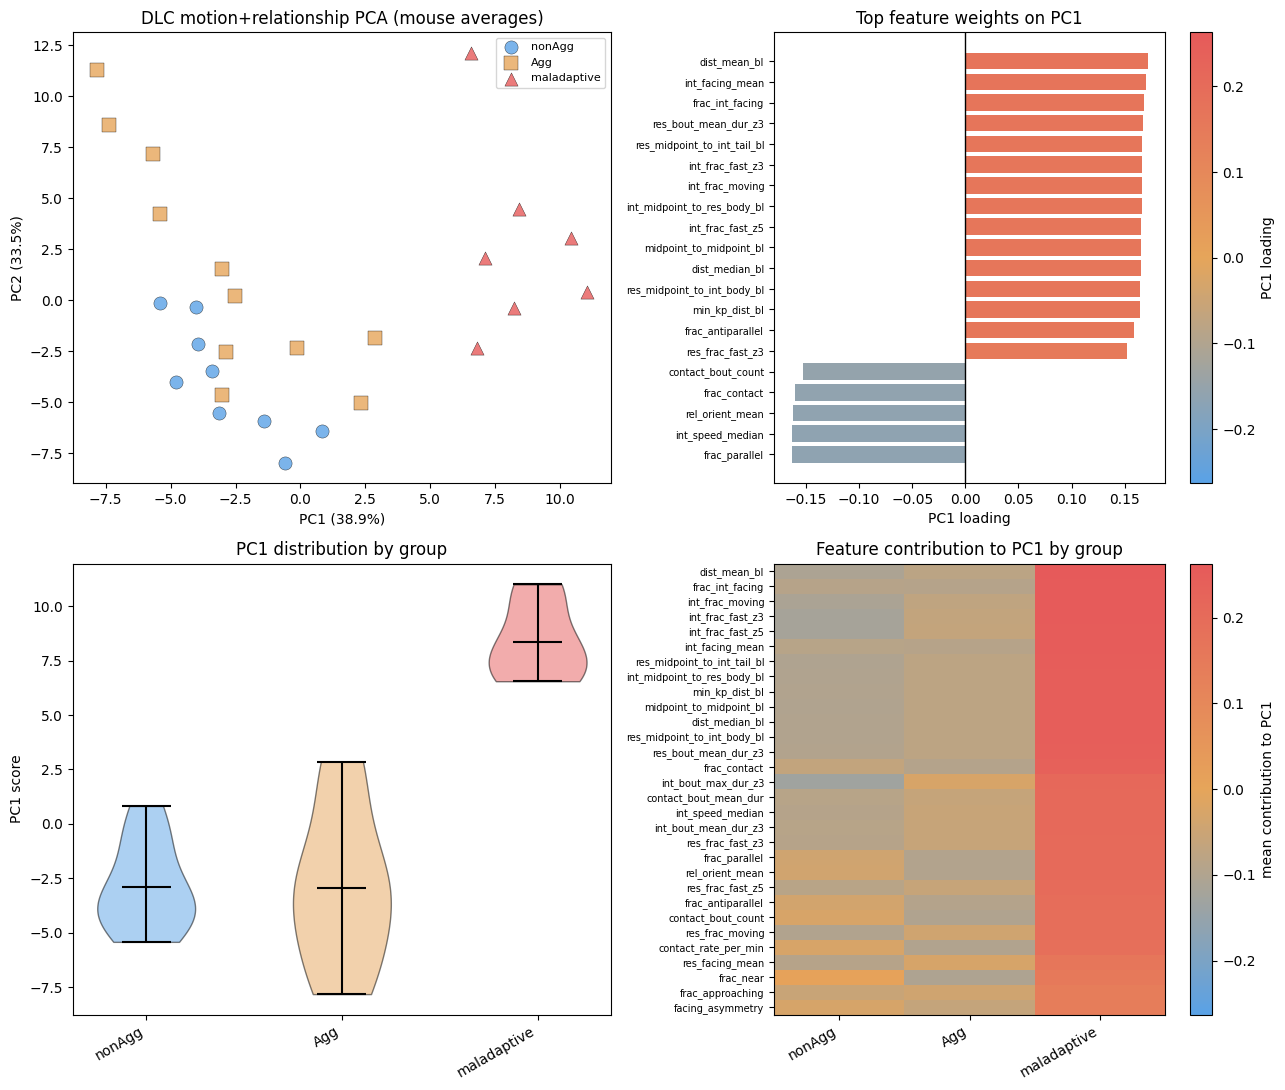

In [39]:
import  matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# =============================================================
# HYPERPARAMETERS
# =============================================================
FEATURE_SELECTION_METHOD = "none"     # "none" (recommended) | "mutual_info" (supervised, circular)
FEATURE_FRACTION = 0.5                 # only used by mutual_info
SIGN_ANCHOR_GROUP = "maladaptive"
RANDOM_STATE = 42

group_colors  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
group_order   = ["nonAgg", "Agg", "maladaptive"]
pc_cmap = LinearSegmentedColormap.from_list("blue_orange_red", ["#5AA2E6", "#E6A55A", "#E65A5A"])

# =============================================================
# baseline-only, one row per mouse
# =============================================================
plot_df = dlc_features_df[dlc_features_df["group"].isin(["nonAgg", "Agg", "maladaptive baseline"])].copy()
plot_df["group_merged"] = plot_df["group"].replace({"maladaptive baseline": "maladaptive"})
plot_df = plot_df.groupby(["mouse", "group_merged"], as_index=False).mean(numeric_only=True)
print(plot_df["group_merged"].value_counts().to_string())

# --- features (all DLC features; NO log; drop metadata + constants) ---
META = {"day", "n_frames", "PC1", "PC2", "original_index"}
feat_cols = [c for c in plot_df.columns if c not in META and c not in ("mouse", "group_merged")]
X_df = plot_df[feat_cols].select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0)
X_df = X_df.loc[:, X_df.std(axis=0) > 0]
X_scaled_all = StandardScaler().fit_transform(X_df)
y = LabelEncoder().fit_transform(plot_df["group_merged"])

# --- feature selection ---
if FEATURE_SELECTION_METHOD == "mutual_info":
    top_n = max(1, int(len(X_df.columns) * FEATURE_FRACTION))
    mi = mutual_info_classif(X_scaled_all, y, random_state=RANDOM_STATE)
    top_features = pd.Series(mi, index=X_df.columns).sort_values(ascending=False).head(top_n).index
else:
    top_features = X_df.columns
print(f"[feature selection] {FEATURE_SELECTION_METHOD} -> {len(top_features)}/{len(X_df.columns)} features")

# =============================================================
# PCA
# =============================================================
X_sel = StandardScaler().fit_transform(X_df[top_features])
pca = PCA(n_components=2).fit(X_sel)
Y = pca.transform(X_sel)
plot_df["PC1"], plot_df["PC2"] = Y[:, 0], Y[:, 1]

# sign convention
if plot_df.groupby("group_merged")["PC1"].mean().idxmax() != SIGN_ANCHOR_GROUP:
    plot_df["PC1"] = -plot_df["PC1"]; pca.components_[0] = -pca.components_[0]

pc1_weights = pd.Series(pca.components_[0], index=top_features, name="PC1_weight")
top_loadings = pc1_weights.reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index).sort_values()

violin_data = [plot_df.loc[plot_df["group_merged"] == g, "PC1"].values for g in group_order]

Xsel_df = pd.DataFrame(X_sel, columns=top_features, index=plot_df.index)
pc1_contrib = Xsel_df.mul(pc1_weights, axis=1); pc1_contrib["group"] = plot_df["group_merged"].values
group_pc1_contrib = pc1_contrib.groupby("group").mean().T
top_heat_n = min(len(top_features), 30)
top_feat_heat = group_pc1_contrib.abs().max(axis=1).sort_values(ascending=False).head(top_heat_n).index
heat = group_pc1_contrib.loc[top_feat_heat, group_order]

max_abs = max(np.abs(top_loadings.values).max(), np.abs(heat.values).max())
norm = Normalize(vmin=-max_abs, vmax=max_abs); sm = ScalarMappable(norm=norm, cmap=pc_cmap); sm.set_array([])

# =============================================================
# FIGURE
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 11), gridspec_kw={"width_ratios": [1.1, 1]})

ax = axes[0, 0]
for g in group_order:
    s = plot_df[plot_df["group_merged"] == g]
    ax.scatter(s["PC1"], s["PC2"], label=g, color=group_colors[g], marker=group_markers[g],
               s=90, alpha=0.8, edgecolor="black", linewidth=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("DLC motion+relationship PCA (mouse averages)"); ax.legend(loc="best", fontsize=8)

ax = axes[0, 1]
ax.barh(top_loadings.index, top_loadings.values, color=[pc_cmap(norm(v)) for v in top_loadings.values])
ax.axvline(0, color="black", lw=1); ax.set_xlabel("PC1 loading"); ax.set_title("Top feature weights on PC1")
ax.tick_params(axis="y", labelsize=7); fig.colorbar(sm, ax=ax).set_label("PC1 loading")

ax = axes[1, 0]
vp = ax.violinplot(violin_data, showmeans=True, showmedians=False)
for body, g in zip(vp["bodies"], group_order):
    body.set_facecolor(group_colors[g]); body.set_edgecolor("black"); body.set_alpha(0.5)
for k in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[k].set_color("black")
ax.set_xticks(np.arange(1, len(group_order)+1)); ax.set_xticklabels(group_order, rotation=30, ha="right")
ax.set_ylabel("PC1 score"); ax.set_title("PC1 distribution by group")

ax = axes[1, 1]
ax.imshow(heat, aspect="auto", cmap=pc_cmap, norm=norm)
ax.set_xticks(np.arange(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(heat.index))); ax.set_yticklabels(heat.index, fontsize=7)
ax.set_title("Feature contribution to PC1 by group")
fig.colorbar(sm, ax=ax).set_label("mean contribution to PC1")

plt.tight_layout(); plt.show()

mouse_dlc_pca = plot_df.copy()